In [7]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/dheeraj/Desktop/Python_practice/Electric motor/measures_v2.csv")

In [8]:
print('Shape:', df.shape)

df.head()

Shape: (1330816, 13)


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


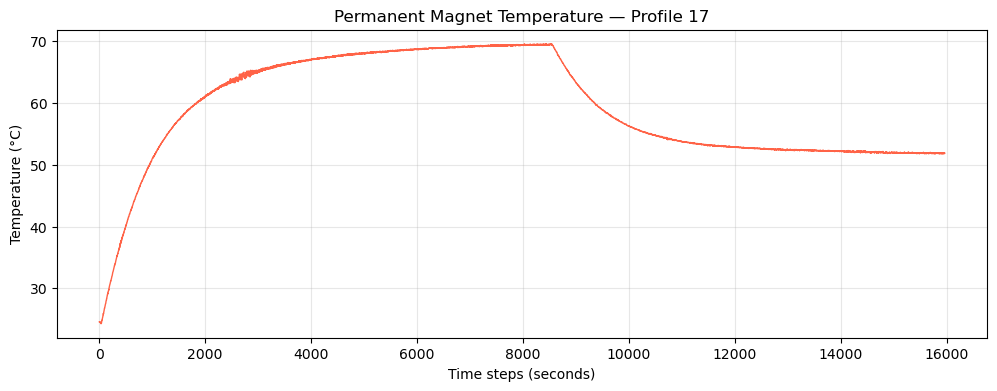

In [9]:
profile = df[df['profile_id'] == 17].reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(profile.index, profile['pm'], color='tomato', linewidth=1)
plt.title('Permanent Magnet Temperature — Profile 17')
plt.xlabel('Time steps (seconds)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

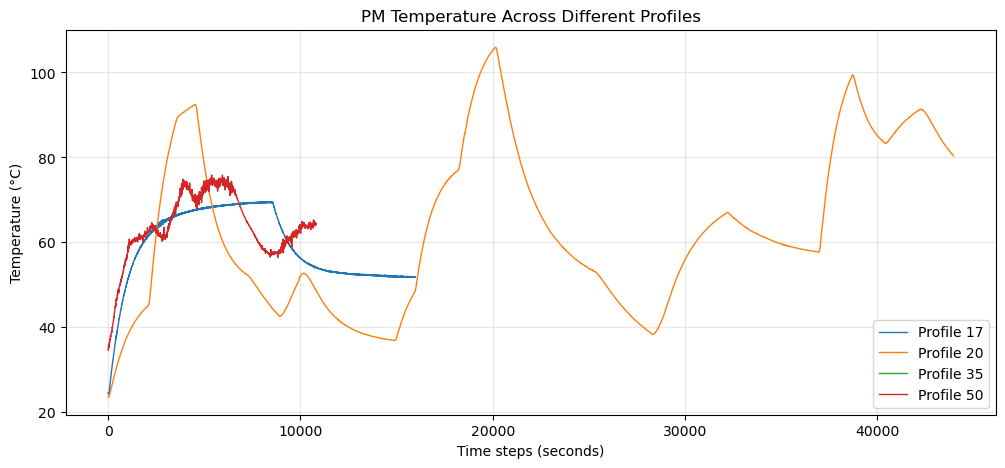

In [10]:
plt.figure(figsize=(12, 5))
for pid in [17, 20, 35, 50]:
    p = df[df['profile_id'] == pid].copy()
    p['time_normalized'] = range(len(p))  # each profile starts from 0
    plt.plot(p['time_normalized'], p['pm'], linewidth=1, label=f'Profile {pid}')

plt.title('PM Temperature Across Different Profiles')
plt.xlabel('Time steps (seconds)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
print(df[df['profile_id'] == 35].shape)
print(df[df['profile_id'] == 35]['pm'].describe())

df.groupby('profile_id').size().sort_values(ascending=False).head(10)

(0, 13)
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: pm, dtype: float64


profile_id
20    43971
6     40388
65    40094
18    37732
66    36476
13    35906
27    35361
4     33424
58    33382
56    33123
dtype: int64

In [12]:
profile_lengths = df.groupby('profile_id').size().sort_values()
print("Shortest profiles:")
print(profile_lengths.head(10))
print()
print("Total rows in dataset:", len(df))
print("Number of profiles:", df['profile_id'].nunique())

Shortest profiles:
profile_id
47     2176
46     2180
52     3726
64     6250
51     6261
59     7475
11     7887
43     8443
78     8445
19    10410
dtype: int64

Total rows in dataset: 1330816
Number of profiles: 69
